# Forecasting Dynamical Systems Without Training Neural Nets
## A FreeFM tutorial with damped oscillators and Lorenz-63

**Author:** [Soon Hoe Lim](https://shoelim.github.io/) (KTH Royal Institute of Technology & Nordita)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1yA9_GlwIiZVtFlZjOXWbYadckxqOvPgu?usp=sharing)

This notebook is a **blog-style tutorial** for FreeFM: a training-free empirical flow matching forecaster for dynamical systems. This training-free model is motivated by finding out what neural flow matching models are implicitly optimizing for in the finite-sample setting, which is the main focus of our paper: https://arxiv.org/abs/2602.08318.

The main question for us in this tutorial is:

> Can we build a probabilistic forecaster directly from observed transition pairs, without training a neural network?

FreeFM answers this by building a **transition memory bank** and using it to define a nonparametric velocity field. Instead of optimizing model weights, the method reuses local transition geometry from the data.

We will study two systems:

1. **Damped harmonic oscillator (DHO)** — a smooth, low-dimensional sanity check.
2. **Lorenz-63** — a chaotic system where long-horizon pointwise prediction is intrinsically difficult.

The notebook contains two experimental regimes:

| Regime | Memory bank | Forecasting question |
|---|---|---|
| **Many-trajectory setup** | transitions pooled from many independent trajectories | Can FreeFM forecast new trajectories from the same system? |
| **Single-trajectory setup** | transitions from one observed time series | Can FreeFM forecast the future of one path? |

## The FreeFM idea

Given transition pairs $(x_0^{(j)},x_1^{(j)})$ extracted from a time series dataset, FreeFM defines Gaussian interpolation paths with mean and variance

$$
m_t^{(j)}=(1-t)x_0^{(j)}+t x_1^{(j)},
\qquad
c_t^2=\sigma_{\min}^2+\sigma^2t(1-t).
$$

The empirical flow matching velocity is

$$
v(t,z)=G_tz+\sum_j\alpha_j(t,z)\left[(x_1^{(j)}-x_0^{(j)})-G_tm_t^{(j)}\right],
\qquad
G_t=\frac{\sigma^2(1-2t)}{2c_t^2},
$$

with Gaussian responsibilities

$$
\alpha_j(t,z) \propto \exp\left\{-\frac{\|z-m_t^{(j)}\|^2}{2c_t^2}\right\}.
$$

Intuitively, for a query point $z$ at interpolation time $t$, FreeFM asks:

> Which observed transition paths pass near this point?

It then blends the directions of those nearby transitions.

A one-step forecast samples

$$
Z_0 \sim N(x_k,\sigma_{\min}^2I),
$$

integrates

$$
\frac{dZ_t}{dt}=v(t,Z_t),\qquad t\in[0,1],
$$

and returns $Z_1$ as a predictive sample for $x_{k+1}$. Repeating this autoregressively gives a probabilistic trajectory forecast.

## Two ways to build the transition memory bank

FreeFM ultimately consumes transition pairs $(x_t,x_{t+1})$. The scientific meaning of the experiment depends on how those pairs are collected.

### Setup A: many-trajectory/source-style setup

We simulate many independent trajectories

$$
X^{(1)}_{0:T},\ldots,X^{(N)}_{0:T},
$$

and form a pooled memory bank

$$
\{(X^{(n)}_t,X^{(n)}_{t+1}) : n=1,\ldots,N,\;t=0,\ldots,T-1\}.
$$

This asks:

> Can FreeFM reuse transition geometry from many example trajectories to forecast a new trajectory?

This is the benchmark-style setting used in **Part I**.

### Setup B: single-trajectory/time-series setup

We observe one long trajectory

$$
X_0,X_1,\ldots,X_T,
$$

split it by time, and build the memory bank only from the observed past.

This asks:

> Can FreeFM forecast the future of one observed time series?

This is the classical forecasting setting used in **Part II**.

The algorithm is the same in both cases. The difference is only the memory bank.

In [1]:
import math, random, time
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

def seed_everything(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Simulate benchmark datasets

We start with two standard dynamical systems.

### Damped harmonic oscillator

- The DHO is a two-dimensional system with state $(x,v)$, where $x$ is position and $v$ is velocity. The phase portrait forms a damped spiral, making it a useful sanity check for a local transition method.

### Lorenz-63

- Lorenz-63 is a three-dimensional chaotic system. It is a good stress test because nearby trajectories separate quickly, so long-horizon pointwise forecasts are not expected to remain close forever.

In [2]:
@dataclass
class DHOParams:
    omega: float = 2.0
    zeta: float = 0.15
    dt: float = 0.01
    steps: int = 500
    process_noise: float = 0.0

@dataclass
class Lorenz63Params:
    sigma: float = 10.0
    rho: float = 28.0
    beta: float = 8.0 / 3.0
    dt: float = 0.01
    steps: int = 500
    process_noise: float = 0.0

@dataclass
class HyperParams:
    sigma_min: float = 0.05
    sigma: float = 0.05


def simulate_dho_sequence_np(params: DHOParams, x0=1.0, v0=0.0):
    """Euler simulation of x'=v, v'=-2*zeta*omega*v-omega^2*x."""
    traj = np.zeros((params.steps, 2), dtype=np.float32)
    x, v = float(x0), float(v0)
    for n in range(params.steps):
        traj[n] = (x, v)
        dx = v
        dv = -2.0 * params.zeta * params.omega * v - params.omega**2 * x
        x = x + params.dt * dx
        v = v + params.dt * dv
        if params.process_noise > 0:
            x += np.sqrt(params.dt) * params.process_noise * np.random.randn()
            v += np.sqrt(params.dt) * params.process_noise * np.random.randn()
    return traj


def simulate_lorenz63_sequence_np(params: Lorenz63Params, x0=(1.0, 1.0, 1.0)):
    """RK4 simulation of Lorenz-63."""
    def f(s):
        x, y, z = s
        return np.array([params.sigma*(y-x), x*(params.rho-z)-y, x*y-params.beta*z], dtype=np.float64)
    s = np.array(x0, dtype=np.float64)
    traj = np.zeros((params.steps, 3), dtype=np.float32)
    dt = params.dt
    for n in range(params.steps):
        traj[n] = s.astype(np.float32)
        k1 = f(s); k2 = f(s + 0.5*dt*k1); k3 = f(s + 0.5*dt*k2); k4 = f(s + dt*k3)
        s = s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        if params.process_noise > 0:
            s += np.sqrt(dt) * params.process_noise * np.random.randn(3)
    return traj


def make_dho_dataset_np(N, params, x0_range=(0.5, 1.5), v0_range=(-0.5, 0.5)):
    return [simulate_dho_sequence_np(params, np.random.uniform(*x0_range), np.random.uniform(*v0_range)) for _ in range(N)]


def make_lorenz_dataset_np(N, params, init_box=(-15, 15)):
    return [simulate_lorenz63_sequence_np(params, np.random.uniform(*init_box, size=3)) for _ in range(N)]


def build_memory_bank_np(seqs):
    if len(seqs) == 0:
        raise ValueError("Need at least one sequence.")
    X0 = np.concatenate([z[:-1] for z in seqs], axis=0).astype(np.float32)
    X1 = np.concatenate([z[1:] for z in seqs], axis=0).astype(np.float32)
    return X0, X1


def split_train_val(seqs, val_frac=0.25):
    n = len(seqs)
    if n < 2:
        raise ValueError("Need at least two sequences.")
    idx = np.random.permutation(n)
    n_val = min(max(1, int(round(n*val_frac))), n-1)
    return [seqs[i] for i in idx[n_val:]], [seqs[i] for i in idx[:n_val]]

## 2. Closed-form empirical velocity field

The next cell implements the FreeFM forecaster.

The important object is the method `velocity(z, t)`, which evaluates the empirical flow matching velocity at query samples `z` and interpolation time `t`.

Two computational modes are supported:

| Setting | Meaning |
|---|---|
| `topk=None` | exact dense empirical field over the full memory bank |
| finite `topk` | faster nearest-neighbor approximation |

The finite-`topk` version is useful when the memory bank is large.

In [3]:
class FreeFMForecaster:
    """Training-free empirical flow-matching forecaster."""
    def __init__(self, X0_np, X1_np, hp: HyperParams, time_grid=101, topk=256, device=torch.device("cpu")):
        if time_grid < 2: raise ValueError("time_grid must be at least 2")
        if hp.sigma_min <= 0: raise ValueError("sigma_min must be positive")
        if hp.sigma < 0: raise ValueError("sigma must be nonnegative")
        self.device, self.hp, self.time_grid, self.topk = device, hp, int(time_grid), topk
        self.X0 = torch.as_tensor(X0_np, dtype=torch.float32, device=device)
        self.X1 = torch.as_tensor(X1_np, dtype=torch.float32, device=device)
        if self.X0.shape != self.X1.shape or self.X0.ndim != 2:
            raise ValueError("X0 and X1 must have shape (M,d)")
        self.M, self.d = self.X0.shape
        if self.topk is not None: self.topk = min(int(self.topk), self.M)
        self._precompute()

    def _precompute(self):
        sigma_min2 = float(self.hp.sigma_min**2)
        sigma2 = float(self.hp.sigma**2)
        self.ts = torch.linspace(0, 1, self.time_grid, device=self.device)
        self.c2 = torch.empty(self.time_grid, device=self.device)
        self.G = torch.empty(self.time_grid, device=self.device)
        self.mu, self.B = [], []
        dX = self.X1 - self.X0
        for i, t_tensor in enumerate(self.ts):
            t = float(t_tensor.item())
            c2_t = max(sigma_min2 + sigma2*t*(1-t), 1e-12)
            G_t = sigma2*(1-2*t)/(2*c2_t) if sigma2 > 0 else 0.0
            m_t = (1-t)*self.X0 + t*self.X1
            B_t = dX - G_t*m_t
            self.c2[i] = c2_t; self.G[i] = G_t
            self.mu.append(m_t); self.B.append(B_t)

    def _idx_t(self, t):
        t = torch.as_tensor(t, device=self.device, dtype=torch.float32).clamp(0, 1)
        return int(torch.round(t*(self.time_grid-1)).long().item())

    @torch.no_grad()
    def drift(self, z, t):
        if z.ndim != 2 or z.shape[1] != self.d:
            raise ValueError(f"z must have shape (B,{self.d})")
        i = self._idx_t(t)
        c2_t, G_t = self.c2[i], self.G[i]
        m_t, B_t = self.mu[i], self.B[i]
        if self.topk is None or self.topk >= self.M:
            diff = z[:, None, :] - m_t[None, :, :]
            weights = torch.softmax(-0.5 * diff.square().sum(-1) / c2_t, dim=1)
            correction = weights @ B_t
        else:
            dist = torch.cdist(z, m_t)
            _, idx = torch.topk(dist, k=self.topk, dim=1, largest=False)
            m_k, B_k = m_t[idx], B_t[idx]
            diff = z[:, None, :] - m_k
            weights = torch.softmax(-0.5 * diff.square().sum(-1) / c2_t, dim=1)
            correction = torch.bmm(weights[:, None, :], B_k).squeeze(1)
        return G_t*z + correction

## 3. Integrators, samplers, and metrics

This section contains the numerical machinery used throughout the notebook:

- Euler and RK4 integrators for the ODE sampler,
- one-step and autoregressive forecast routines,
- simple metrics such as mean squared error,
- helpers for building transition memory banks.

The key forecasting loop is autoregressive: FreeFM predicts one step ahead, then uses that prediction as the starting point for the next step.

In [4]:
@torch.no_grad()
def euler_integrate_batched(f, z0, steps):
    if steps <= 0: raise ValueError("steps must be positive")
    z = z0.clone(); h = 1.0/steps; t = torch.zeros((), dtype=z.dtype, device=z.device)
    for _ in range(steps):
        z = z + h*f(z, t); t = t + h
    return z

@torch.no_grad()
def rk4_integrate_batched(f, z0, steps):
    if steps <= 0: raise ValueError("steps must be positive")
    z = z0.clone(); h = 1.0/steps; t = torch.zeros((), dtype=z.dtype, device=z.device)
    for _ in range(steps):
        k1=f(z,t); k2=f(z+0.5*h*k1,t+0.5*h); k3=f(z+0.5*h*k2,t+0.5*h); k4=f(z+h*k3,t+h)
        z = z + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4); t = t + h
    return z

@torch.no_grad()
def forecast_one_step(model, x, S=64, ode_steps=20, integrator="euler"):
    x = torch.as_tensor(x, dtype=torch.float32, device=model.device)
    z = x[None, :] + model.hp.sigma_min*torch.randn(S, x.numel(), device=model.device)
    f = lambda zz, tt: model.drift(zz, tt)
    samples = euler_integrate_batched(f, z, ode_steps) if integrator == "euler" else rk4_integrate_batched(f, z, ode_steps)
    return samples.mean(0), samples

@torch.no_grad()
def autoregressive_forecast(model, x_start, horizon, S=64, ode_steps=20, integrator="euler", refresh_noise=False):
    x = torch.as_tensor(x_start, dtype=torch.float32, device=model.device)
    particles = x[None, :] + model.hp.sigma_min*torch.randn(S, x.numel(), device=model.device)
    means, ensemble = [], []
    f = lambda zz, tt: model.drift(zz, tt)
    for _ in range(horizon):
        if refresh_noise:
            particles = particles + model.hp.sigma_min*torch.randn_like(particles)
        particles = euler_integrate_batched(f, particles, ode_steps) if integrator == "euler" else rk4_integrate_batched(f, particles, ode_steps)
        means.append(particles.mean(0).cpu().numpy())
        ensemble.append(particles.cpu().numpy())
    return np.stack(means), np.stack(ensemble)  # (H,d), (H,S,d)


def mse_np(y, yhat): return float(np.mean((np.asarray(y)-np.asarray(yhat))**2))

def crps_np(samples, y_true):
    samples, y_true = np.asarray(samples), np.asarray(y_true)
    term1 = np.mean(np.abs(samples - y_true[None, :]), axis=0)
    term2 = 0.5*np.mean(np.abs(samples[:, None, :] - samples[None, :, :]), axis=(0,1))
    return float(np.mean(term1-term2))

def acf_1d(x, max_lag=50):
    x = np.asarray(x, dtype=float); x = x - x.mean(); var = np.mean(x*x) + 1e-12
    return np.array([np.mean(x[:len(x)-lag]*x[lag:])/var for lag in range(max_lag+1)])

## 4. Validation search for path widths

FreeFM has two main path-width hyperparameters:

| Hyperparameter | Role |
|---|---|
| `sigma_min` | initial predictive noise and endpoint regularization |
| `sigma` | width of the interpolation paths |

The grid search below chooses these values using validation transitions. The implementation is intentionally simple: it evaluates one-step predictive error over a validation memory bank.

In [5]:
def grid_search_freefm(train_seqs, val_seqs, sigma_min_grid, sigma_grid, topk=64, time_grid=101,
                       S=32, ode_steps=20, integrator="euler", max_val_pairs=200, device=device):
    X0_train, X1_train = build_memory_bank_np(train_seqs)
    X0_val, X1_val = build_memory_bank_np(val_seqs)
    idx = np.arange(len(X0_val))
    if len(idx) > max_val_pairs:
        idx = np.random.choice(idx, size=max_val_pairs, replace=False)
    rows=[]; best=None; best_model=None
    for sigma_min in tqdm(sigma_min_grid, desc="sigma_min"):
        for sigma in sigma_grid:
            model = FreeFMForecaster(X0_train, X1_train, HyperParams(float(sigma_min), float(sigma)), time_grid, topk, device)
            mses=[]; crps=[]
            for j in idx:
                mu, samples = forecast_one_step(model, X0_val[j], S=S, ode_steps=ode_steps, integrator=integrator)
                mses.append(mse_np(X1_val[j], mu.cpu().numpy()))
                crps.append(crps_np(samples.cpu().numpy(), X1_val[j]))
            row={"sigma_min":sigma_min,"sigma":sigma,"val_mse":float(np.mean(mses)),"val_crps":float(np.mean(crps))}
            rows.append(row)
            if best is None or row["val_crps"] < best["val_crps"]:
                best=row; best_model=model
    return pd.DataFrame(rows).sort_values("val_crps").reset_index(drop=True), best, best_model

## 5. Plotting helpers

We will inspect:

- coordinate-wise forecast trajectories,
- uncertainty bands from forecast ensembles,
- phase portraits,
- autocorrelation comparisons.

For chaotic systems such as Lorenz-63, phase-space and statistical plots are often more meaningful than full-horizon pointwise error alone.

In [6]:
def plot_conditional_forecast(true_full, T_obs, pred_mean, pred_ensemble, dt, title_prefix):
    H, d = pred_mean.shape; t = np.arange(T_obs+H)*dt
    labels = ["x","v"] if d == 2 else ["x","y","z"]
    for k, lab in enumerate(labels):
        plt.figure(figsize=(10,4))
        plt.plot(t, true_full[:T_obs+H,k], label=f"true {lab}")
        pred_full = np.concatenate([true_full[:T_obs,k], pred_mean[:,k]])
        plt.plot(t, pred_full, "--", label=f"forecast mean {lab}")
        lo, hi = np.quantile(pred_ensemble[:,:,k], [0.1,0.9], axis=1)
        plt.fill_between(t[T_obs:], lo, hi, alpha=0.25, label="10-90% band")
        plt.axvline(t[T_obs-1], linestyle=":", label="forecast start")
        plt.title(f"{title_prefix}: conditional forecast for {lab}(t)"); plt.xlabel("time"); plt.ylabel(lab); plt.legend(); plt.show()

def plot_phase(true_future, pred_mean, title):
    d=pred_mean.shape[1]
    if d == 2:
        plt.figure(figsize=(5,5)); plt.plot(true_future[:,0],true_future[:,1],label="true future"); plt.plot(pred_mean[:,0],pred_mean[:,1],"--",label="forecast mean")
        plt.xlabel("x"); plt.ylabel("v"); plt.title(title); plt.legend(); plt.show()
    else:
        fig=plt.figure(figsize=(7,6)); ax=fig.add_subplot(111, projection="3d")
        ax.plot(true_future[:,0],true_future[:,1],true_future[:,2],label="true future")
        ax.plot(pred_mean[:,0],pred_mean[:,1],pred_mean[:,2],"--",label="forecast mean")
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.set_title(title); ax.legend(); plt.show()

def plot_acf_compare(true_future, pred_mean, max_lag, dt, title):
    labels=["x","v"] if true_future.shape[1] == 2 else ["x","y","z"]
    lags=np.arange(max_lag+1)*dt; plt.figure(figsize=(8,4))
    for k, lab in enumerate(labels):
        plt.plot(lags, acf_1d(true_future[:,k], max_lag), label=f"true {lab}")
        plt.plot(lags, acf_1d(pred_mean[:,k], max_lag), "--", label=f"pred {lab}")
    plt.title(title); plt.xlabel("lag"); plt.ylabel("ACF"); plt.legend(ncol=2); plt.show()

# Part I — Many-trajectory/source-style setup

In the first two demos, we generate multiple independent trajectories and split them by trajectory:

```python
all_seqs = make_dataset(...)
train_val_seqs = all_seqs[:-N_test]
test_seqs = all_seqs[-N_test:]
train_seqs, val_seqs = split_train_val(train_val_seqs)
```

The FreeFM memory bank pools transitions across all training trajectories:

```python
X0_train, X1_train = build_memory_bank_np(train_seqs)
```

This is the source-style benchmark regime. It is useful when we want a transition rule that generalizes across different initial conditions.

## 6. Demo A — damped harmonic oscillator, many trajectories

We first test FreeFM on DHO trajectories. This is the favorable case: the dynamics are smooth, low-dimensional, and the training trajectories cover the relevant phase-space region.

The first plot shows the training trajectories in phase space. These curves are the source of the transition memory bank.

DHO split: train=14, val=4, test=2


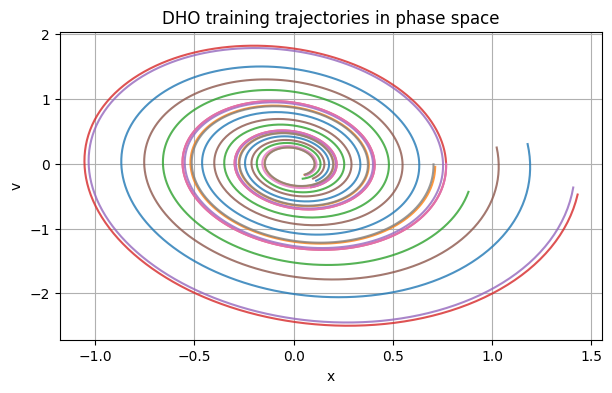

In [7]:
seed_everything(7)
dho_params = DHOParams(steps=500, dt=0.02, omega=2.0, zeta=0.12)
dho_all = make_dho_dataset_np(20, dho_params)
dho_train_val, dho_test = dho_all[:-2], dho_all[-2:]
dho_train, dho_val = split_train_val(dho_train_val, 0.25)
print(f"DHO split: train={len(dho_train)}, val={len(dho_val)}, test={len(dho_test)}")
plt.figure(figsize=(7,4))
for z in dho_train[:8]: plt.plot(z[:,0], z[:,1], alpha=0.8)
plt.title("DHO training trajectories in phase space"); plt.xlabel("x"); plt.ylabel("v"); plt.show()

In [8]:
dho_df, dho_best, dho_model = grid_search_freefm(
    dho_train, dho_val,
    sigma_min_grid=[0.01,0.03,0.05,0.08], sigma_grid=[0.01,0.03,0.05,0.08],
    topk=16, time_grid=101, S=32, ode_steps=10, max_val_pairs=180, device=device)
display(dho_df.head(10)); print("Best DHO:", dho_best)

sigma_min:   0%|          | 0/4 [00:00<?, ?it/s]

,sigma_min,sigma,val_mse,val_crps
0,0.01,0.01,0.000005,0.002553
1,0.01,0.03,0.000046,0.003929
2,0.03,0.05,0.000026,0.007399
3,0.03,0.01,0.000027,0.007400
4,0.03,0.03,0.000030,0.007609
5,0.03,0.08,0.000043,0.007713
6,0.01,0.05,0.000275,0.008470
7,0.05,0.05,0.000075,0.012454
8,0.05,0.08,0.000079,0.012474
9,0.05,0.03,0.000083,0.012627


Best DHO: {'sigma_min': 0.01, 'sigma': 0.01, 'val_mse': 4.776883328351368e-06, 'val_crps': 0.0025526517445945904}


The training phase-space plot shows what FreeFM can remember. In this many-trajectory setting, the memory bank contains transitions from several nearby spirals, so the test trajectory is likely to remain close to observed transition geometry.

DHO forecast MSE: 1.6459049220429733e-05
DHO terminal error: 0.0065400167


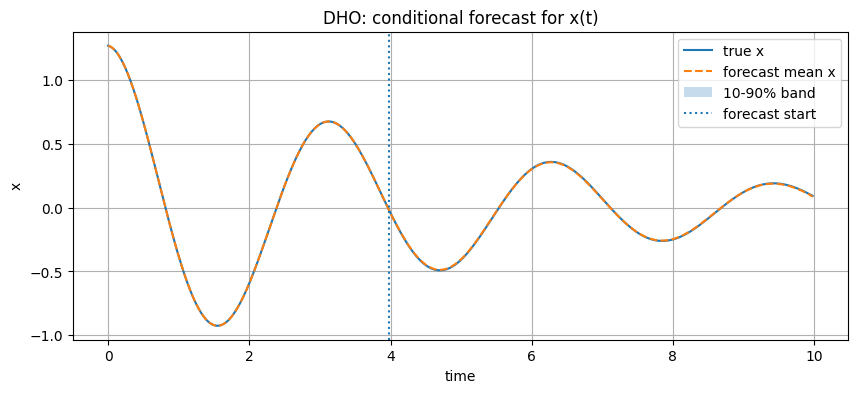

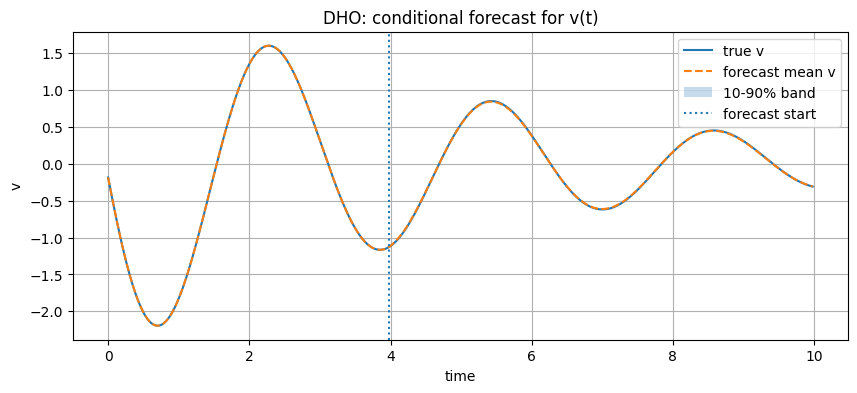

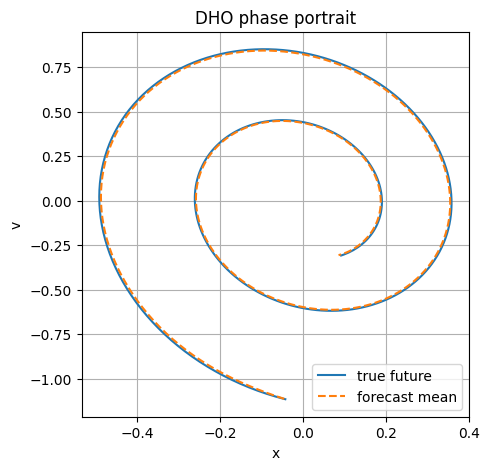

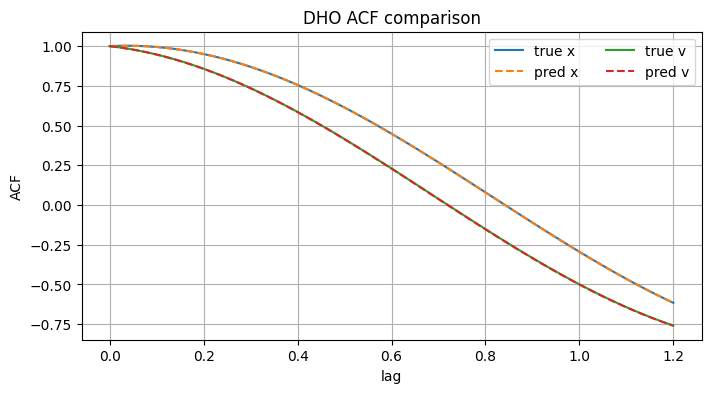

In [9]:
T_obs=200; H=300; test=dho_test[0]
pred_mean, pred_ens = autoregressive_forecast(dho_model, test[T_obs-1], H, S=32, ode_steps=10)
future_true = test[T_obs:T_obs+H]
print("DHO forecast MSE:", mse_np(future_true, pred_mean))
print("DHO terminal error:", np.linalg.norm(future_true[-1]-pred_mean[-1]))
plot_conditional_forecast(test, T_obs, pred_mean, pred_ens, dho_params.dt, "DHO")
plot_phase(future_true, pred_mean, "DHO phase portrait")
plot_acf_compare(future_true, pred_mean, 60, dho_params.dt, "DHO ACF comparison")

## 7. Demo B — Lorenz-63, many trajectories

Lorenz-63 is chaotic. This changes what we should expect.

A short-window forecast can be meaningful, but full-horizon pointwise matching will eventually break down because small errors grow rapidly. For this reason, we inspect:

- short-window MSE,
- full-horizon MSE,
- phase-space plausibility,
- autocorrelation behavior.

After validation selects the path widths, we forecast autoregressively from the observed prefix of a held-out DHO trajectory. The forecast mean and ensemble band summarize the predictive distribution.

Lorenz split: train=14, val=4, test=2


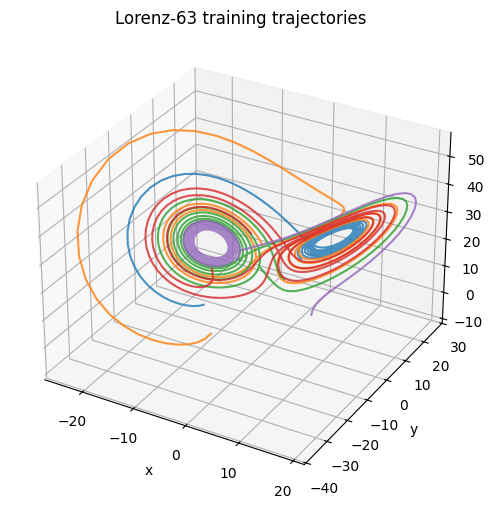

In [10]:
seed_everything(11)
lorenz_params = Lorenz63Params(steps=500, dt=0.01)
lorenz_all = make_lorenz_dataset_np(20, lorenz_params, init_box=(-12,12))
lorenz_train_val, lorenz_test = lorenz_all[:-2], lorenz_all[-2:]
lorenz_train, lorenz_val = split_train_val(lorenz_train_val, 0.25)
print(f"Lorenz split: train={len(lorenz_train)}, val={len(lorenz_val)}, test={len(lorenz_test)}")
fig=plt.figure(figsize=(7,6)); ax=fig.add_subplot(111, projection="3d")
for z in lorenz_train[:5]: ax.plot(z[:,0],z[:,1],z[:,2],alpha=0.8)
ax.set_title("Lorenz-63 training trajectories"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); plt.show()

In [11]:
lorenz_df, lorenz_best, lorenz_model = grid_search_freefm(
    lorenz_train, lorenz_val,
    sigma_min_grid=[0.01,0.02,0.05,0.1], sigma_grid=[0.01,0.02,0.05,0.1],
    topk=256, time_grid=101, S=32, ode_steps=20, max_val_pairs=200, device=device)
display(lorenz_df.head(10)); print("Best Lorenz:", lorenz_best)

sigma_min:   0%|          | 0/4 [00:00<?, ?it/s]

,sigma_min,sigma,val_mse,val_crps
0,0.02,0.01,0.004217,0.026277
1,0.05,0.02,0.004034,0.026764
2,0.05,0.01,0.004369,0.027041
3,0.02,0.02,0.005610,0.029245
4,0.05,0.05,0.005615,0.029712
5,0.01,0.01,0.005622,0.031378
6,0.10,0.01,0.004001,0.034390
7,0.10,0.05,0.003986,0.034608
8,0.10,0.02,0.004377,0.035226
9,0.10,0.10,0.005311,0.036757


Best Lorenz: {'sigma_min': 0.02, 'sigma': 0.01, 'val_mse': 0.004216738942398593, 'val_crps': 0.02627749799983576}


Lorenz short-window MSE (first 50): 0.005830812267959118
Lorenz full-horizon MSE: 0.18233194947242737


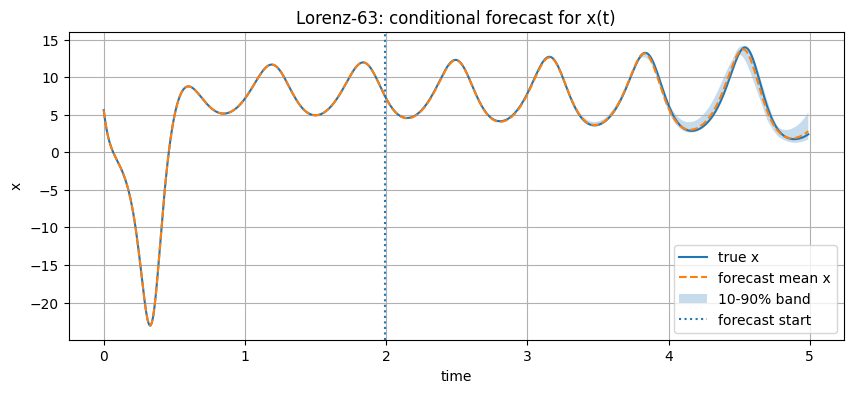

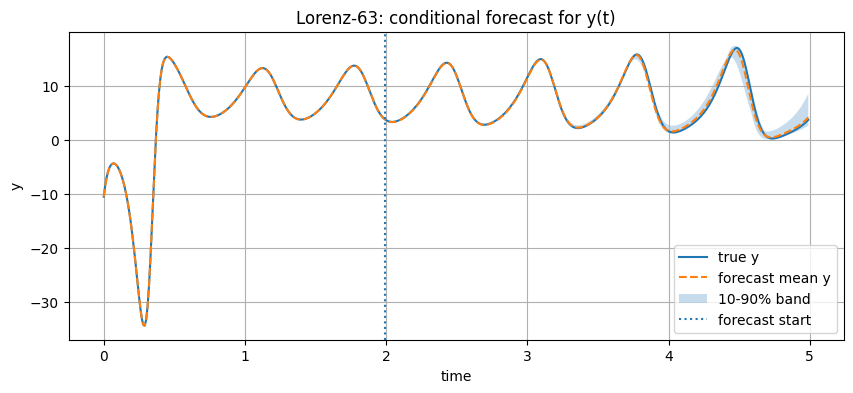

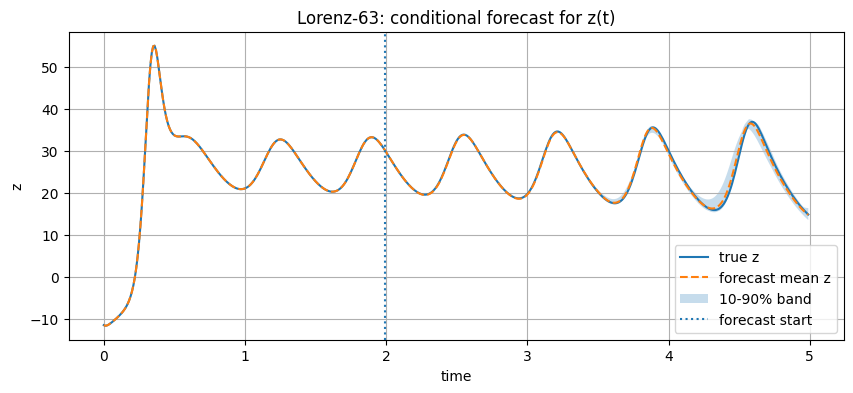

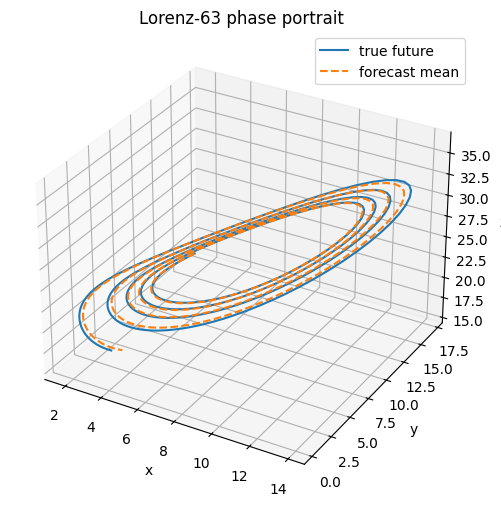

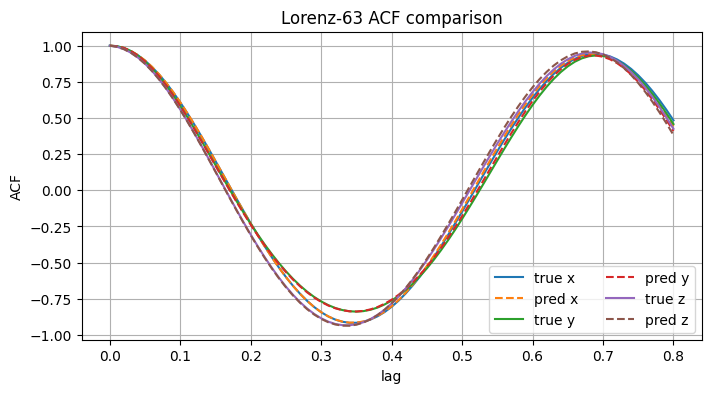

In [12]:
T_obs=200; H=300; test=lorenz_test[0]
pred_mean, pred_ens = autoregressive_forecast(lorenz_model, test[T_obs-1], H, S=32, ode_steps=20)
future_true = test[T_obs:T_obs+H]
print("Lorenz short-window MSE (first 50):", mse_np(future_true[:50], pred_mean[:50]))
print("Lorenz full-horizon MSE:", mse_np(future_true, pred_mean))
plot_conditional_forecast(test, T_obs, pred_mean, pred_ens, lorenz_params.dt, "Lorenz-63")
plot_phase(future_true, pred_mean, "Lorenz-63 phase portrait")
plot_acf_compare(future_true, pred_mean, 80, lorenz_params.dt, "Lorenz-63 ACF comparison")

For Lorenz-63, the training trajectories explore a chaotic attractor. The memory bank is richer than in the DHO example, but the dynamics are also much more sensitive to small errors.

# Part II — Single-trajectory/time series setup

We now run the same FreeFM idea in a different data regime.

## Forecasting problem

We observe one ordered path $X_0, X_1, \ldots, X_{T_{\mathrm{obs}}-1},$ and want to forecast the held-out future $X_{T_{\mathrm{obs}}}, \ldots, X_{T_{\mathrm{obs}}+H-1}.$

The observed prefix is split again into an earlier training segment and a later validation segment:

```text
training segment | validation segment | held-out future
```

The validation segment is observed before the forecast boundary, so it may be used for hyperparameter selection. The held-out future is used only after forecasting for evaluation.

## Memory banks

During validation, the memory bank is built only from the training segment:

```python
X0_train, X1_train = build_memory_bank_np([train_traj])
```

After choosing $(\sigma_{\min}, \sigma)$, we rebuild the final memory bank using all observed data before the forecast boundary:

```python
X0_trainval, X1_trainval = build_memory_bank_np([observed_traj])
```

This final rebuild is fair because both the training and validation segments are known before forecasting starts. The future segment remains untouched.

The key lesson is coverage:

> FreeFM is highly sample-efficient when the memory bank covers the future region, but fragile when the forecast leaves the observed support.

## Validation protocol for the single-trajectory setting

In the single-trajectory experiments below, we use the validation segment to choose $(\sigma_{\min},\sigma)$. After selecting those hyperparameters, we rebuild the final FreeFM memory bank using **all observed transitions before the forecast boundary**, i.e. train plus validation.

```text
train | validation | held-out future
```

The held-out future is still used only for evaluation. This is usually the fairest final forecasting protocol because the validation segment is observed before forecasting.

## Implementation helper for the single-trajectory experiment

The next cell is self-contained at the experiment-design level: it performs the time split, validation search, final memory-bank rebuild, autoregressive forecast, and diagnostic plots for one observed trajectory.

Inputs:

- `traj`: one complete simulated or observed path, ordered in time.
- `T_obs`: number of observed states available before forecasting.
- `H`: forecast horizon.
- `sigma_min_grid`, `sigma_grid`: validation grid for the FreeFM path widths.

Outputs include the train/validation/future arrays, the selected hyperparameters, the final model, and the forecast ensemble.

In [53]:
def plot_phase(true, pred_mean, title):
    d = pred_mean.shape[1]

    if d == 2:
        plt.figure(figsize=(5, 5))
        plt.plot(true[:, 0], true[:, 1], label="true")
        plt.plot(pred_mean[:, 0], pred_mean[:, 1], "--", label="forecast mean")
        plt.xlabel("x")
        plt.ylabel("v")
        plt.title(title)
        plt.legend()
        plt.axis("equal")
        plt.show()

    elif d == 3:
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111, projection="3d")
        ax.plot(true[:, 0], true[:, 1], true[:, 2], label="true")
        ax.plot(
            pred_mean[:, 0],
            pred_mean[:, 1],
            pred_mean[:, 2],
            "--",
            label="forecast mean",
        )
        ax.set_title(title)
        ax.legend()
        plt.show()

def run_single_trajectory_demo(
    traj,
    T_obs,
    H,
    sigma_min_grid,
    sigma_grid,
    topk,
    time_grid,
    S_grid,
    ode_steps_grid,
    S_forecast,
    ode_steps_forecast,
    title,
    dt,
    max_val_pairs=2000,
):
    train_traj, val_traj, observed_traj, future_true = time_split_single_trajectory(
        traj,
        T_obs=T_obs,
        H=H,
        val_frac_within_observed=0.25,
    )

    print(f"{title} single-trajectory split:")
    print(f"  train segment: {train_traj.shape}")
    print(f"  validation segment: {val_traj.shape}")
    print(f"  observed context: {observed_traj.shape}")
    print(f"  held-out future: {future_true.shape}")

    # Use the validation segment only for hyperparameter selection.
    df, best, _ = grid_search_freefm(
        [train_traj],
        [val_traj],
        sigma_min_grid=sigma_min_grid,
        sigma_grid=sigma_grid,
        topk=topk,
        time_grid=time_grid,
        S=S_grid,
        ode_steps=ode_steps_grid,
        max_val_pairs=max_val_pairs,
        device=device,
    )

    display(df.head(10))
    print(f"Best {title} single-trajectory hyperparameters:", best)

    # After hyperparameters are selected, rebuild the final memory bank using
    # all observed data before the forecast boundary: train + validation.
    X0_trainval, X1_trainval = build_memory_bank_np([observed_traj])

    model = FreeFMForecaster(
        X0_trainval,
        X1_trainval,
        HyperParams(float(best["sigma_min"]), float(best["sigma"])),
        time_grid=time_grid,
        topk=topk,
        device=device,
    )

    print(f"Final {title} memory bank: {X0_trainval.shape[0]} train+val transitions")

    pred_mean, pred_ens = autoregressive_forecast(
        model,
        observed_traj[-1],
        H,
        S=S_forecast,
        ode_steps=ode_steps_forecast,
    )

    print(f"{title} single-trajectory forecast MSE:", mse_np(future_true, pred_mean))
    print(
        f"{title} single-trajectory terminal error:",
        np.linalg.norm(future_true[-1] - pred_mean[-1]),
    )

    print("future_true shape:", future_true.shape)
    print("pred_mean shape:  ", pred_mean.shape)
    print("pred_ens shape:   ", pred_ens.shape)

    assert len(future_true) == len(pred_mean), (
        len(future_true),
        len(pred_mean),
    )

    t_future = np.arange(H) * dt
    d = pred_mean.shape[1]

    if d == 2:
        labels = ["x", "v"]
    elif d == 3:
        labels = ["x", "y", "z"]
    else:
        labels = [f"component {k}" for k in range(d)]

    for k, lab in enumerate(labels):
        plt.figure(figsize=(10, 4))

        plt.plot(
            t_future,
            future_true[:, k],
            label=f"true future {lab}",
        )

        plt.plot(
            t_future,
            pred_mean[:, k],
            "--",
            label=f"forecast mean {lab}",
        )

        lo, hi = np.quantile(pred_ens[:, :, k], [0.1, 0.9], axis=1)

        plt.fill_between(
            t_future,
            lo,
            hi,
            alpha=0.25,
            label="10-90% forecast band",
        )

        plt.title(f"{title} single-trajectory forecast: {lab}(t)")
        plt.xlabel("forecast time")
        plt.ylabel(lab)
        plt.legend()
        plt.show()


    # ------------------------------------------------------------
    # Phase portrait over exactly the same H future states
    # ------------------------------------------------------------
   # Phase portrait over exactly the same H future states
    plot_phase(
        future_true[:H],
        pred_mean[:H],
        f"{title} single-trajectory phase portrait",
    )

    plot_acf_compare(
        future_true,
        pred_mean,
        min(60, H - 1),
        dt,
        f"{title} single-trajectory ACF comparison",
    )

    return {
        "train_traj": train_traj,
        "val_traj": val_traj,
        "observed_traj": observed_traj,
        "future_true": future_true,
        "df": df,
        "best": best,
        "model": model,
        "pred_mean": pred_mean,
        "pred_ens": pred_ens,
    }

Before running the single-trajectory experiments, we create trajectories long enough for the requested observed context and forecast horizon.

DHO single-trajectory split:
  train segment: (300, 2)
  validation segment: (100, 2)
  observed context: (400, 2)
  held-out future: (100, 2)


sigma_min:   0%|          | 0/4 [00:00<?, ?it/s]

,sigma_min,sigma,val_mse,val_crps
0,0.03,0.01,0.000074,0.008182
1,0.01,0.01,0.000270,0.008338
2,0.03,0.03,0.000196,0.010409
3,0.05,0.01,0.000116,0.012761
4,0.05,0.03,0.000120,0.012886
5,0.05,0.05,0.000182,0.014354
6,0.08,0.03,0.000232,0.020172
7,0.08,0.01,0.000232,0.020320
8,0.08,0.08,0.000232,0.020663
9,0.08,0.05,0.000271,0.020835


Best DHO single-trajectory hyperparameters: {'sigma_min': 0.03, 'sigma': 0.01, 'val_mse': 7.404722451252438e-05, 'val_crps': 0.00818220345830225}
Final DHO memory bank: 399 train+val transitions
DHO single-trajectory forecast MSE: 0.010385305620729923
DHO single-trajectory terminal error: 0.30879626
future_true shape: (100, 2)
pred_mean shape:   (100, 2)
pred_ens shape:    (100, 32, 2)


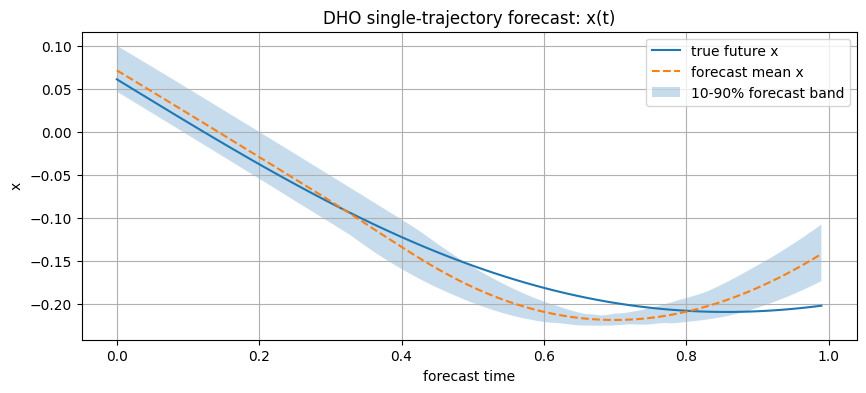

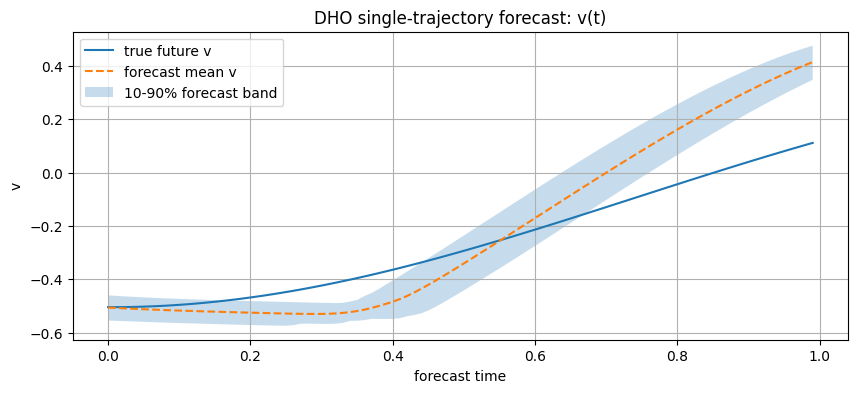

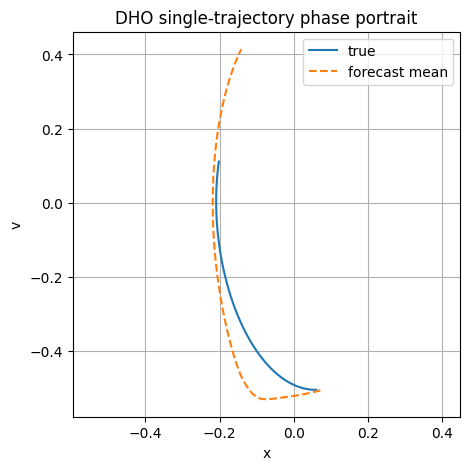

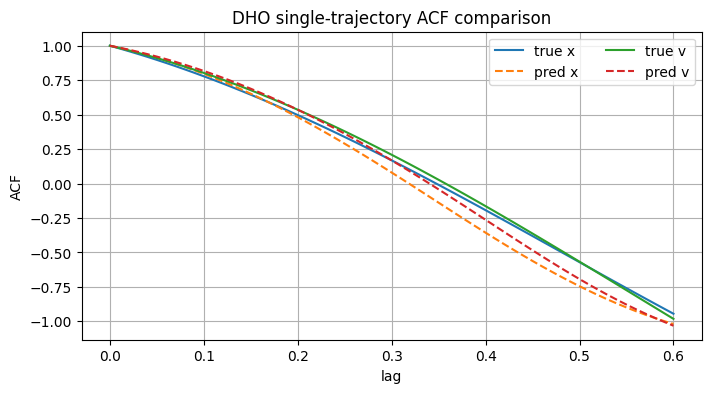

In [56]:
# Single-trajectory DHO demo
seed_everything(7)

T_obs = 400
H = 100

dho_single_params = DHOParams(
    steps=T_obs + H,
    dt=0.01,
    omega=2.0,
    zeta=0.12,
    process_noise=0.0,
)

dho_single_traj = simulate_dho_sequence_np(
    dho_single_params,
    x0=np.random.uniform(0.5, 1.5),
    v0=np.random.uniform(-0.5, 0.5),
)

dho_single_result = run_single_trajectory_demo(
    traj=dho_single_traj,
    T_obs=T_obs,
    H=H,
    sigma_min_grid=[0.01, 0.03, 0.05, 0.08],
    sigma_grid=[0.01, 0.03, 0.05, 0.08],
    topk=256,
    time_grid=101,
    S_grid=32,
    ode_steps_grid=100,
    S_forecast=32,
    ode_steps_forecast=100,
    title="DHO",
    dt=dho_single_params.dt,
    max_val_pairs=2000,
)


Lorenz-63 single-trajectory split:
  train segment: (300, 3)
  validation segment: (100, 3)
  observed context: (400, 3)
  held-out future: (100, 3)


sigma_min:   0%|          | 0/4 [00:00<?, ?it/s]

,sigma_min,sigma,val_mse,val_crps
0,0.01,0.01,0.000007,0.002670
1,0.01,0.02,0.000010,0.002801
2,0.01,0.05,0.000022,0.003331
3,0.02,0.02,0.000015,0.004995
4,0.01,0.10,0.000078,0.005187
5,0.02,0.01,0.000020,0.005199
6,0.02,0.05,0.000024,0.005354
7,0.02,0.10,0.000034,0.005658
8,0.05,0.01,0.000077,0.012588
9,0.05,0.02,0.000093,0.012818


Best Lorenz-63 single-trajectory hyperparameters: {'sigma_min': 0.01, 'sigma': 0.01, 'val_mse': 7.4490899253466315e-06, 'val_crps': 0.0026698459922853443}
Final Lorenz-63 memory bank: 399 train+val transitions
Lorenz-63 single-trajectory forecast MSE: 0.012657221406698227
Lorenz-63 single-trajectory terminal error: 0.35972816
future_true shape: (100, 3)
pred_mean shape:   (100, 3)
pred_ens shape:    (100, 32, 3)


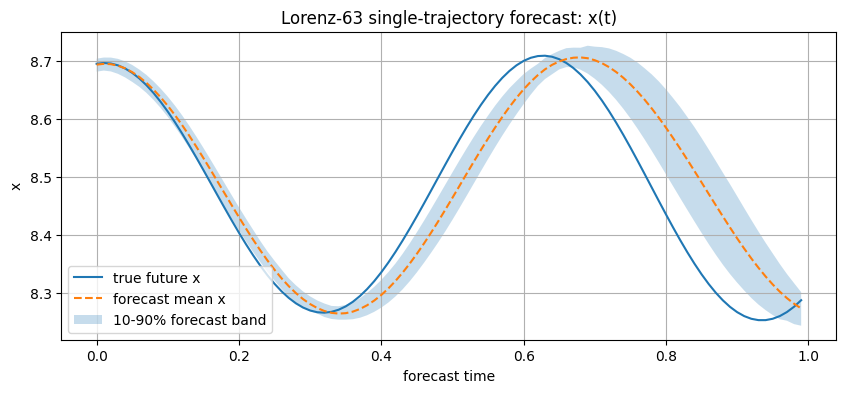

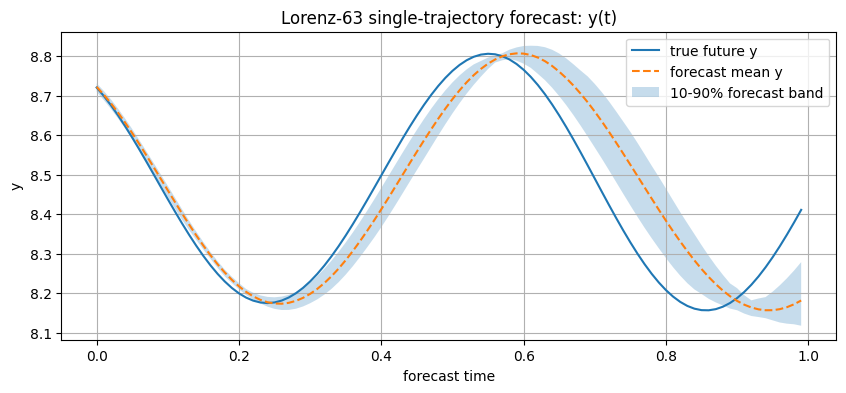

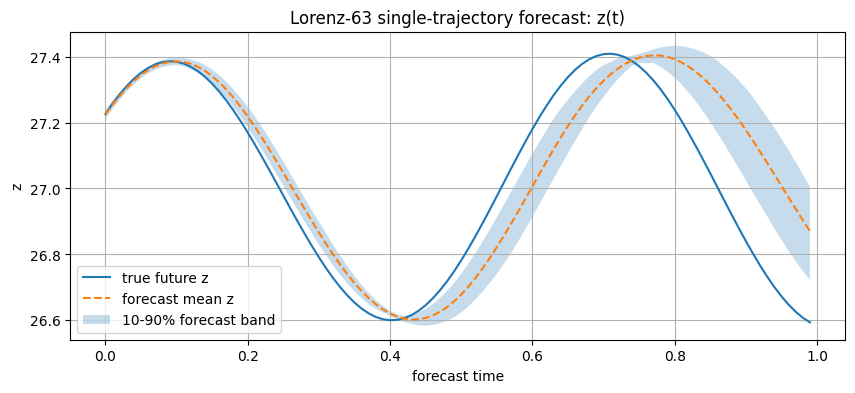

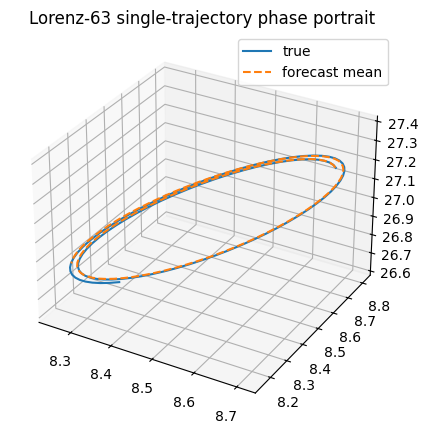

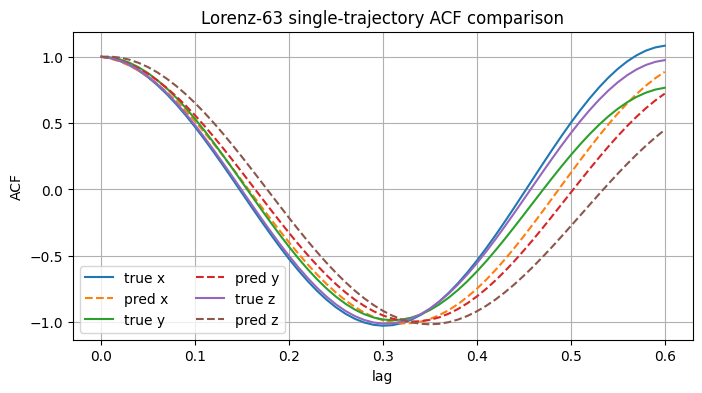

In [58]:
# Single-trajectory Lorenz-63 demo
seed_everything(7)

T_obs = 400
H = 100

lorenz_single_params = Lorenz63Params(
    steps=T_obs + H,
    dt=0.01,
    sigma=10.0,
    rho=28.0,
    beta=8.0 / 3.0,
    process_noise=0.0,
)

lorenz_single_traj = simulate_lorenz63_sequence_np(
    lorenz_single_params,
    x0=tuple(np.random.uniform(-12, 12, size=3)),
)

lorenz_single_result = run_single_trajectory_demo(
    traj=lorenz_single_traj,
    T_obs=T_obs,
    H=H,
    sigma_min_grid=[0.01, 0.02, 0.05, 0.1],
    sigma_grid=[0.01, 0.02, 0.05, 0.1],
    topk=256,
    time_grid=101,
    S_grid=32,
    ode_steps_grid=100,
    S_forecast=32,
    ode_steps_forecast=100,
    title="Lorenz-63",
    dt=lorenz_single_params.dt,
    max_val_pairs=2000,
)


## Comparing the two setups

The two regimes are both valid, but they answer different forecasting questions.

| Setup | Memory bank comes from | Validation split | Forecast question |
|---|---|---|---|
| Many-trajectory/source-style | many independent trajectories | held-out trajectories | Can FreeFM forecast new trajectories from the same system? |
| Single-trajectory/time series | one historical path | later segment of the same path | Can FreeFM forecast the future of one observed time series? |

The training-free model is the same in both cases. The only difference is how we construct the transition pairs for the memory bank.

This distinction is central. FreeFM does not learn a compressed latent representation of the entire dynamical system. It retrieves and blends local transition geometry. Therefore, the quality of the memory bank determines the quality of the forecast.

In the single-trajectory DHO case, the memory bank comes from one observed damped spiral. This can still work well when the future remains close to the observed region.

## 9. Practical notes

- Use `topk=None` for the exact dense empirical field on small memory banks.
- Use a finite `topk` for a faster nearest-neighbor approximation on larger memory banks.
- Larger `topk`, more ODE steps, and RK4 can give smoother but slower forecasts.
- For Lorenz-63, exact long-horizon path matching is not expected because the system is chaotic.
- For noisy dynamical systems, set `refresh_noise=True` in `autoregressive_forecast` to inject fresh uncertainty at each discrete step.

## 10. Main takeaway

FreeFM is best understood as a **memory-based flow matching forecaster** which replaces parametric learning with local transition retrieval.

Its strengths are:

- no neural net training,
- simple implementation,
- interpretable local transition reuse,
- natural probabilistic forecasts through ensembles.

Its weaknesses are:

- dependence on memory bank coverage,
- nearest-neighbor cost for large datasets,
- limited extrapolation outside observed support,
- long-horizon fragility on chaotic systems.

FreeFM can forecast without training, but it cannot forecast accurately without sufficient coverage. In the single-trajectory case, the same idea is more fragile, as we see from the above experiments. A single path may not provide enough local transition coverage for stable long-horizon forecasts.

What we presented so far is a very basic version of FreeFM. **There are various directions we could explore to improve the model, opening up a whole new paradigm for sequence modeling.**